In [1]:
#premodel and seed generation implementation:

import numpy as np
import random

seed = 7
np.random.seed(seed) # for numpy
random.seed(seed) # for random and other libraries
print(f'Global Random seed set to: {seed}')

Global Random seed set to: 7


## Problem 1: Automatic Gift Recognizer
- uses data_proccesing
- uses model_builder
- uses model_trainer

In [2]:
from src.data_proccesing import explore_data, split_data_into_3sets
# loading and displaying data
dataset = np.load("data/dataset.npz")
X, y = dataset["X"], dataset["y"]
explore_data(X,y) # prints class distribution
X_train, y_train, X_val, y_val, X_test, y_test = split_data_into_3sets(X, y, randomseed = seed) #splits data into train, val and test
#showimage(X_train, 5) # shows first 5 images in training set

Shape of X: (13067, 400)
Shape of y: (13067,)
Number of classes: 15
Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
    Class  Count
0       0    546
1       1    900
2       2    804
3       3    454
4       4   1022
5       5   1362
6       6    858
7       7    557
8       8    888
9       9    834
10     10    782
11     11   1601
12     12    702
13     13    884
14     14    873


**Our implementation with 3 k folds**

In [3]:

from src.model_builder import buildmodel
from src.model_trainer_validator import train_eval_model_cv
from itertools import product # https://docs.python.org/3/library/itertools.html#itertools.product
from sklearn.metrics import accuracy_score

# Source for sklearn model parameters:
# RandomForestClassifier: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
# SVC: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
# LogisticRegression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
# KNeighborsClassifier: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
#defining hyperparameter grids for each model:
'''
rf_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'max_features': ['sqrt', 'log2']
}
svm_grid = {
    'C': [0.1, 10],
    'kernel': ['linear', 'rbf'],
}
lr_grid = {
    'C': [0.1, 10],
}
knn_grid = {
    'n_neighbors': [3, 7]
}
'''
rf_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'max_features': ['sqrt', 'log2']
}
knn_grid = {
    'n_neighbors': [3, 7]
}

# loop through all of the model instances with different hyperparameters defined above
# use the model trainer and model selector here to find the best model and hyperparameters
model_grids = {
    'RF': rf_grid,
    #'SVM': svm_grid,
    #'LR': lr_grid,
    'KNN': knn_grid
}
print('Our kfold implementation without the use of Gridsearch')

best_individ_models = []

for model_name, param_grid in model_grids.items():
    print(f'Starting {model_name} 3-fold cross-validation...')
    for params in product(*param_grid.values()):
        kwargs = dict(zip(param_grid.keys(), params))
        model = buildmodel(model_name, **kwargs)
        score = train_eval_model_cv(model, X_train, y_train, X_val, y_val, cv=3, seed=seed) #accuracy score as performance measure
        best_individ_models.append((model_name, kwargs, score))
    
#evaluate models and hyperparameters
best_individ_models.sort(key=lambda x: x[2], reverse=True)
print("\nTop 5 models and hyperparameters:")
for model_name, params, score in best_individ_models[:5]:
    print(f"Model: {model_name}, Params: {params}, CV Score: {score:.4f}")

best_name, best_params, best_cv = best_individ_models[0]
print(f"\nSelected winner: {best_name} with params {best_params} (CV={best_cv:.4f})")

#rebuild with train and val data
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

winner = buildmodel(best_name, **best_params)
winner.fit(X_trainval, y_trainval)

#evaluate best model on test data:
y_test_pred = winner.predict(X_test)
test_acc  = accuracy_score(y_test, y_test_pred)


Our kfold implementation without the use of Gridsearch
Starting RF 3-fold cross-validation...
Mean accuracy over 3 folds: 0.7270
Mean accuracy over 3 folds: 0.7179
Mean accuracy over 3 folds: 0.7072
Mean accuracy over 3 folds: 0.6936
Mean accuracy over 3 folds: 0.7350
Mean accuracy over 3 folds: 0.7264
Mean accuracy over 3 folds: 0.7106
Mean accuracy over 3 folds: 0.7014
Starting KNN 3-fold cross-validation...
Mean accuracy over 3 folds: 0.6564
Mean accuracy over 3 folds: 0.6169

Top 5 models and hyperparameters:
Model: RF, Params: {'n_estimators': 100, 'max_depth': None, 'max_features': 'sqrt'}, CV Score: 0.7350
Model: RF, Params: {'n_estimators': 50, 'max_depth': None, 'max_features': 'sqrt'}, CV Score: 0.7270
Model: RF, Params: {'n_estimators': 100, 'max_depth': None, 'max_features': 'log2'}, CV Score: 0.7264
Model: RF, Params: {'n_estimators': 50, 'max_depth': None, 'max_features': 'log2'}, CV Score: 0.7179
Model: RF, Params: {'n_estimators': 100, 'max_depth': 10, 'max_features': '

SKLearns implementation of GridSearchCV

In [4]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from src.model_builder import buildmodel
SEED = seed
'''
models_and_grids = {
    'RF': (buildmodel('RF'), {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'max_features': ['sqrt', 'log2']
    }),
    'SVM': (buildmodel('SVM'), {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf']
    }),
    'LR': (buildmodel('LR'), {
        'C': [0.1, 1, 10],
        'solver': ['liblinear']
    }),
    'KNN': (buildmodel('KNN'), {
        'n_neighbors': [3, 5, 7]
    })
}
'''
models_and_grids = {
    'RF': (buildmodel('RF'), {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'max_features': ['sqrt', 'log2']
    }),
    'KNN': (buildmodel('KNN'), {
        'n_neighbors': [3, 5, 7]
    })
}


best_models = []
print('sklearns gridsearch and stratified k fold for simplicity')
for name, (model, param_grid) in models_and_grids.items():
    print(f'\nTuning {name}...')
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)
    print(f'Best {name} params: {grid.best_params_}')
    print(f'Best {name} score: {grid.best_score_:.4f}')
    best_models.append((name, grid.best_estimator_, grid.best_params_, grid.best_score_))

best_models.sort(key=lambda r: r[3], reverse=True)
winner_name, winner_est, winner_params, winner_cv = best_models[0]

winner_est.fit(X_trainval, y_trainval)

y_test_pred = winner_est.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f'\nWinner: {winner_name} | params={winner_params} | CV={winner_cv:.4f}')
print('with test accuracy score:')
print(test_acc)



sklearns gridsearch and stratified k fold for simplicity

Tuning RF...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best RF params: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 200}
Best RF score: 0.7361

Tuning KNN...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best KNN params: {'n_neighbors': 3}
Best KNN score: 0.6424

Winner: RF | params={'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 200} | CV=0.7361
with test accuracy score:
0.7664456909739928


## Problem 2: PCAA analysis
- uses pcaaanalysis.py to visualize and analyze training data
- methodology: 
- ensure SEED and SOLVER are fixed
- Ensure each part of proccess where randomization can skew reproducibility is accounted for
- On the training split, create a cv with stratified k fold to account for randomization and 
- run GridSearchCV with a Pipeline([Scaler, PCA, Model]).
- PCA will be refit in each CV fold.
- Evaluate the tuned model(s) on the validation set to pick the best approach.
- Final training: refit the chosen pipeline (Scaler+PCA+Model with the chosen hyperparams) on train+validation.
- Final report: evaluate once on the test set.

In [5]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from src.model_builder import buildmodel_pca
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.base import clone

# global variables(SEED defined earlier)
SOLVER = 'full'
SEED = seed #for clarity

models_and_grids = {
    # SVM with PCA
    'SVM_PCA': (buildmodel_pca('SVM_PCA', randomseed=SEED, pca_solver=SOLVER), {
        'pca__n_components': [0.80, 0.90, 100],   # try different numbers of components with cumalative explained variance >= these numbers
        'clf__kernel': ['rbf'],
        'clf__C': [0.1, 1, 10],
        'clf__gamma': ['scale', 0.01, 0.001]
    }),
    # KNN with PCA
    'KNN_PCA': (buildmodel_pca('KNN_PCA', randomseed=SEED, pca_solver=SOLVER), {
        'pca__n_components': [0.80, 0.95, 64],
        'clf__n_neighbors': [3, 5, 7],
        'clf__weights': ['uniform', 'distance']
    }),
    #logistic regression with PCA
    'LR_PCA': (buildmodel_pca('LR_PCA', randomseed=SEED, pca_solver=SOLVER), {
        'pca__n_components': [0.80, 0.95, 64], #pass 64 sklearn keeps exactly 64 PCs
        'clf__C': [0.1, 1, 10],
        'clf__penalty': ['l2'],
        'clf__solver': ['lbfgs']
    }),
    # Random forest (no PCA)
    'RF': (buildmodel_pca('RF', randomseed= SEED), {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'max_features': ['sqrt', 'log2']
    })
}

best_models_train = {}
val_results = {}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED) #for reproducibility and stratified splits which is important for class-imbalanced data

for name, (model, param_grid) in models_and_grids.items():
    print(f"\nTuning {name}...")
    grid = GridSearchCV(model, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1) # performs the k-fold cross-validation
    # for each canadate pca_n_components and model hyperparameter combination
        #Fit StandardScaler on the train-fold, transform it.

        #Fit PCA on that transformed train-fold, transform it.

        #Fit clf on those PC scores.z

        #Transform the val-fold with the same scaler/PCA and score it.
    grid.fit(X_train, y_train)  # <- PCA+scaler are fit only on training folds; this is a pipeline and calls pca.transform(scaled_X) before passing to model's .fit()
    print(f"Best {name} params: {grid.best_params_}")
    print(f"Best {name} CV score: {grid.best_score_:.4f}")
    best_models_train[name] = grid.best_estimator_ #GridSearchCV object with the best found model refit on full training set
    tuned = best_models_train[name]
    print('')
    # For PCA models, print actual k chosen and cumulative explained variance
    if name in ['SVM_PCA', 'LR_PCA', 'KNN_PCA']:
        print("PCA model detected, extracting PCA info...")
        pipe = best_models_train[name]
        pca    = pipe.named_steps['pca']
        k = getattr(pca, 'n_components_',None)  # resolved number of components chosen by PCA during fit
        evr_sum = pca.explained_variance_ratio_.sum()
        d_orig = X_train.shape[1]
        d_pc = pca.components_.shape[0] 
        print(f"\n{name}")
        print(f"  Original dims: {d_orig}")
        print(f"  Chosen k (resolved): {k}  (pca__n_components in grid may have been 0.xx or an int)")
        print(f"  Cumulative explained variance (TRAIN fit): {evr_sum:.4f}")

    # Validate on validation set
    print('')
    print("Validating on validation set...")
    y_val_pred = tuned.predict(X_val) #calls pca.transform(scaled_X_val) before passing to model's .predict()
    accuracy = accuracy_score(y_val, y_val_pred)
    f1w = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)
    f1m = f1_score(y_val, y_val_pred, average='macro', zero_division=0)
    val_results[name] = {'accuracy': accuracy, 'f1_weighted': f1w, 'f1_macro': f1m}
    print(f"{name} on VALIDATION: {accuracy:.4f}, F1-weighted: {f1w:.4f}, F1-macro: {f1m:.4f}")
    print("-" * 40)

best_model = max(val_results, key=lambda k: val_results[k]['f1_macro']) #returns model name based on best f1_macro
print(f"\nBest model on validation set: {best_model} with f1_macro {val_results[best_model]['f1_macro']:.4f}")



print('tuning best model on val+train')
#refit best model on full training+validation set
winner = best_models_train[best_model] #actual model not string
X_train_val = np.vstack((X_train, X_val))
y_train_val = np.hstack((y_train, y_val))
final_model = clone(winner).fit(X_train_val, y_train_val)

#Test
print('Evaluating winner model on held-out test set...')
y_test_pred = final_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1m = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
test_f1w = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

print('Final evaluation on TEST set:')
print(f"{best_model}  acc={test_acc:.4f}, f1_weighted={test_f1w:.4f}, f1_macro={test_f1m:.4f}")
print(classification_report(y_test, y_test_pred, digits=3))
print(confusion_matrix(y_test, y_test_pred))


# === What each “Tuning …” block means ===
# 
# • “Fitting 3 folds …”:
#     GridSearchCV is running 3-fold cross-validation on the TRAIN split
#     for many hyperparameter combinations.
#
# • “Best … params”:
#     The hyperparameters that achieved the highest CV score (per your
#     scoring/refit setting) on the TRAIN folds.
#
# • “Best … CV score”:
#     The average CV score over the 3 folds for that best combo.
#     NOTE: this is NOT the held-out validation set.
#
# • PCA info (for *_PCA models):
#     - Original dims: number of raw features (e.g., 400 pixels).
#     - Chosen k (resolved): the actual number of principal components
#       PCA used after fitting. If you supplied a float (e.g., 0.8),
#       PCA picked the smallest k whose cumulative explained variance ≥ 80%.
#       (Example: k = 90 for 0.8.)
#     - Cumulative explained variance: total variance retained by those k
#       components (e.g., ~0.8015 = 80.15%).
#
# • “Validating on validation set …”:
#     Take the tuned pipeline (refit on the full TRAIN split) and evaluate
#     ONCE on the VALIDATION set. Report:
#       - Accuracy: overall correctness.
#       - F1-weighted: class F1s averaged with weights by class size
#         (tracks accuracy but considers precision/recall).
#       - F1-macro: unweighted mean of per-class F1s (each class counts
#         equally). Use this as the selection metric.






Tuning SVM_PCA...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best SVM_PCA params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'pca__n_components': 0.8}
Best SVM_PCA CV score: 0.7805

PCA model detected, extracting PCA info...

SVM_PCA
  Original dims: 400
  Chosen k (resolved): 90  (pca__n_components in grid may have been 0.xx or an int)
  Cumulative explained variance (TRAIN fit): 0.8015

Validating on validation set...
SVM_PCA on VALIDATION: 0.7980, F1-weighted: 0.7963, F1-macro: 0.7872
----------------------------------------

Tuning KNN_PCA...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best KNN_PCA params: {'clf__n_neighbors': 5, 'clf__weights': 'distance', 'pca__n_components': 64}
Best KNN_PCA CV score: 0.7563

PCA model detected, extracting PCA info...

KNN_PCA
  Original dims: 400
  Chosen k (resolved): 64  (pca__n_components in grid may have been 0.xx or an int)
  Cumulative explained variance (TRAIN fit): 0.7359

Validating 

## Problem 3: Bad Data

distored data(X_screen shape): (405, 400)
(FAIL) No label array present. Showing the first 10 of 405 images.
(FAIL) Found 405 unlabeled data points out of 405 total.
Reusing winner PCA: target=0.8, resolved_k=90
THRESHOLD:26.40914025671188
Table of first 5 indexes of the preditction, and how far away from centroid:
----Threshold = 26.4091 (99.0th percentile of distances)
----Flagged 92 out of 405 => 22.72%


,idx,predicted_class,dist_to_class_centroid,flag_corrupt
0,0,5,12.908192,False
1,1,10,15.327296,False
2,2,9,17.395347,False
3,3,11,12.224061,False
4,4,12,24.661576,False


Worst-Kindices: [90, 242, 70, 149, 49, 92, 213, 223, 384, 209, 341, 190]


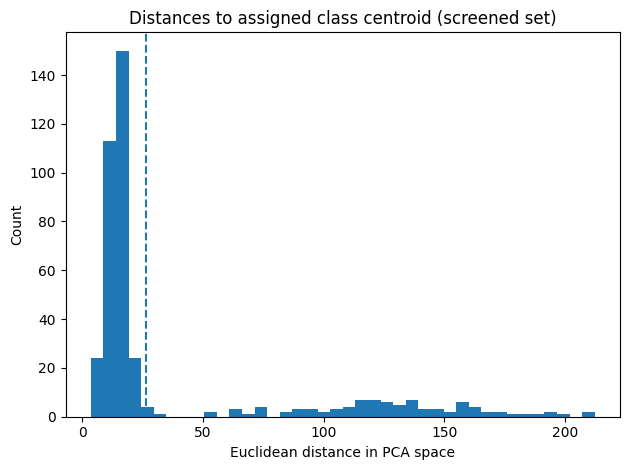


Showing the 12 worst offenders (highest distance to class centroid):


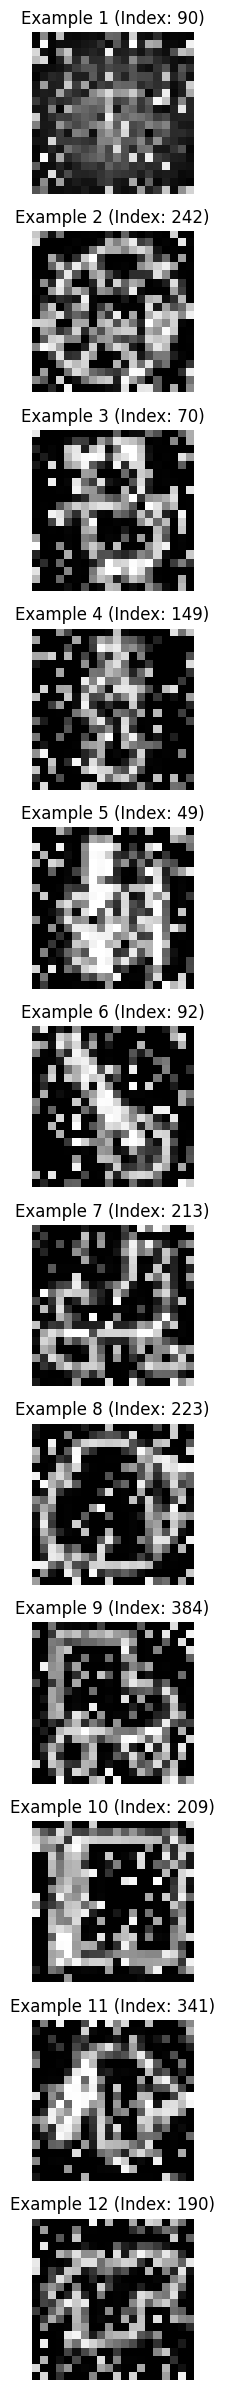

showing examples that are close but above the threshold


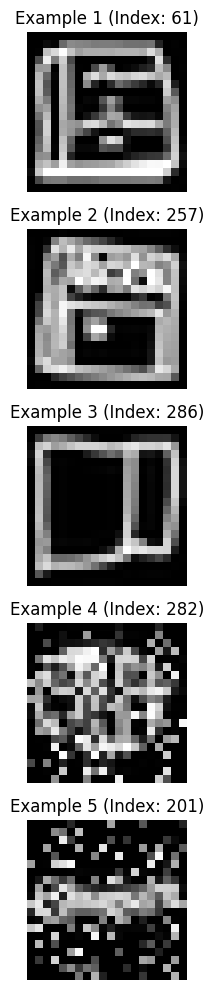

In [6]:
#Task 3: find corrupted images
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from src.bad_data_implement import load_npz_X_y, show_bad_data_examples


# paths
screen_path  = Path('data/dataset_corrupted.npz')
X_screen, y_screen = load_npz_X_y(screen_path)
print('distored data(X_screen shape):', X_screen.shape)

# print data points without labels and how many there are:
if y_screen is None:
    unlabeled_idx = list(range(len(X_screen))) 
    print(f'(FAIL) No label array present. Showing the first 10 of {len(X_screen)} images.')
    #show_bad_data_examples(X_screen, indices=np.arange(min(10, len(X_screen)))) this didnt work
else: # find indices of unlabeled data points and print how many there are:
    unlabeled_idx = []
    for i, lab in enumerate(y_screen):
        missing = False
        # treat -1 or NaN (for numeric) and '' (for strings) as unlabeled
        if isinstance(lab, (int, float, np.number)):
            missing = (lab == -1) or (isinstance(lab, float) and np.isnan(lab))
        else:
            missing = (str(lab) == '')
        if missing:
            unlabeled_idx.append(i)
# ^ this didnt work because the entire data set is without labels but now we know....
print(f'(FAIL) Found {len(unlabeled_idx)} unlabeled data points out of {len(X_screen)} total.')
#^ 405/405

# can try:
# find the centroids for each class in PCA space from problem 2 and flag weird/distorted data points

# reuse the winner's scaler + PCA (assumes Pipeline with 'scale' and 'pca') ---
scale_A = final_model.named_steps['scale'] #reusing fitted scaler from final model
pca_A   = final_model.named_steps['pca']
print(f"Reusing winner PCA: target={pca_A.n_components}, resolved_k={getattr(pca_A, 'n_components_', None)}")
# create per-class centroids in that SAME PCA space using clean ref set
# X_train_val, y_train_val were created above when you refit the winner
Z_ref = pca_A.transform(scale_A.transform(X_train_val)) # use of transform because we dont want to refit
classes = np.unique(y_train_val) #finding the unique classes in the training+validation set
centroids = {c: Z_ref[y_train_val == c].mean(axis=0) for c in classes} #finding the middle point of each class in PCA space

# Class assignment for screened set: used tuned winner
y_screen_pred = final_model.predict(X_screen)

#Project screened data to PCA space and compute distances to assigned class centroid
#large distance from centroid = weird data point
Z_screen = pca_A.transform(scale_A.transform(X_screen))
dists_screen = np.array([
    np.linalg.norm(z - centroids[c])
    for z, c in zip(Z_screen, y_screen_pred)
])

# Build threshold from REF distances (unsupervised) to identify corrupt data
dists_ref = np.array([
    np.linalg.norm(z - centroids[c])
    for z, c in zip(Z_ref, y_train_val)
])
use_percentile = True
percentile = 99.0 # can adjust this value if needed
if use_percentile:
    threshold = np.percentile(dists_ref, percentile)
    thr_note = f'{percentile}th percentile of distances'
else:
    threshold = dists_ref.mean() + 3.0 * dists_ref.std()
    thr_note = 'mean + 3·std of clean distances'

print(f'THRESHOLD:{threshold}')
is_corrupt = dists_screen > threshold


# results & quick inspection
print('Table of first 5 indexes of the preditction, and how far away from centroid:')
print(f'----Threshold = {threshold:.4f} ({thr_note})')
print(f'----Flagged {is_corrupt.sum()} out of {len(is_corrupt)} => {100*is_corrupt.mean():.2f}%')
results = pd.DataFrame({
    "idx": np.arange(len(dists_screen)),
    "predicted_class": y_screen_pred,
    "dist_to_class_centroid": dists_screen,
    "flag_corrupt": is_corrupt
})
display(results.head())

# Worst offenders
K = min(12, len(dists_screen))
worst_idx = np.argsort(-dists_screen)[:K]
print('Worst-Kindices:', worst_idx.tolist())

# Histogram showing 
# x axis: distance from each screened sample to the centroid
# y axis: number of images at that distance

# basically there is a large number of examples that have under the threshold in distance,
# the ones above the threshold: 26.4... are deemed as being abnormal or distorted
plt.figure()
plt.hist(dists_screen, bins=40)
plt.axvline(threshold, linestyle="--")
plt.title('Distances to assigned class centroid (screened set)')
plt.xlabel('Euclidean distance in PCA space')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#show worst offenders
print(f'\nShowing the {K} worst offenders (highest distance to class centroid):')
show_bad_data_examples(X_screen, indices=worst_idx)

# Borderline examples: "close but above" the threshold ---
margin = dists_screen - threshold     # takes only distances above threshold     
band = 30.0     # how far above threshold                            
borderline_mask = (margin >= 0) & (margin <= band)

borderline_idx = np.where(borderline_mask)[0]
# sort by how barely they exceed the cutoff (closest first)
borderline_sorted = borderline_idx[np.argsort(margin[borderline_idx])]

print('showing examples that are close but above the threshold')
show_bad_data_examples(X_screen, indices = borderline_sorted[:12])

